In [31]:
!pip install torch torch-geometric -q

In [32]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data

In [33]:
data = pd.read_csv("gnn_fraud_dataset.csv")
edges = pd.read_csv("gnn_edges.csv")

data.head()

,transaction_id,customer_id,amount,transaction_type,merchant_category,timestamp,age,country,account_age_days,device_id,ip_id,ip_country,hour,transactions_last_hour,is_fraud_ring,fraud
0,1,8445,65.54,POS,Electronics,2023-09-24 01:23:00,41,USA,2656,device_2056,ip_3474,UK,1,1,0,0
1,2,3856,72.56,Online,Travel,2023-04-03 06:30:00,57,India,1073,device_595,ip_4880,India,6,7,0,0
2,3,7064,64.55,POS,Shopping,2023-10-06 23:26:00,31,Germany,2217,device_1258,ip_5155,USA,23,1,0,0
3,4,5171,246.46,ATM,Food,2023-05-02 02:50:00,62,Germany,2046,device_2089,ip_825,Germany,2,7,0,0
4,5,4433,62.39,POS,Electronics,2023-02-13 00:26:00,39,India,2134,device_4470,ip_6074,Germany,0,4,0,0


In [34]:
# Normalization
from sklearn.preprocessing import StandardScaler

features = data[["amount", "hour", "transactions_last_hour", "account_age_days", "age"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

data[["amount", "hour", "transactions_last_hour", "account_age_days", "age"]] = scaled_features

In [35]:
# Create unique node names
customer_nodes = ["cust_" + str(x) for x in data["customer_id"].unique()]
transaction_nodes = ["txn_" + str(x) for x in data["transaction_id"].unique()]
device_nodes = data["device_id"].unique().tolist()
ip_nodes = data["ip_id"].unique().tolist()

all_nodes = customer_nodes + transaction_nodes + device_nodes + ip_nodes

In [36]:
node_to_idx = {node: i for i, node in enumerate(all_nodes)}

In [37]:
edge_index = torch.tensor([
    [node_to_idx[src] for src in edges["source"]],
    [node_to_idx[tgt] for tgt in edges["target"]]
], dtype=torch.long)

In [38]:
num_nodes = len(all_nodes)
num_features = 6

x = torch.zeros((num_nodes, num_features))

In [39]:
node_type_map = {}

for node in all_nodes:
    if node.startswith("cust"):
        node_type_map[node] = 0
    elif node.startswith("txn"):
        node_type_map[node] = 1
    elif node.startswith("device"):
        node_type_map[node] = 2
    else:
        node_type_map[node] = 3
        
for _, row in data.iterrows():
    idx = node_to_idx["txn_" + str(row["transaction_id"])]

    x[idx] = torch.tensor([
    row["amount"],
    row["hour"],
    row["transactions_last_hour"],
    row["account_age_days"],
    row["age"],
    node_type_map[node]
], dtype=torch.float)

In [40]:
y = torch.zeros(num_nodes, dtype=torch.long)

for _, row in data.iterrows():
    idx = node_to_idx["txn_" + str(row["transaction_id"])]
    y[idx] = int(row["fraud"])

In [41]:
from sklearn.model_selection import train_test_split

txn_indices = [
    node_to_idx["txn_" + str(tid)]
    for tid in data["transaction_id"]
]

train_idx, test_idx = train_test_split(txn_indices, test_size=0.2, random_state=42)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

In [42]:
graph_data = Data(x=x, edge_index=edge_index, y=y)

graph_data.train_mask = train_mask
graph_data.test_mask = test_mask

In [43]:
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F

class GraphSAGE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = SAGEConv(6, 32)
        self.conv2 = SAGEConv(32, 16)
        self.conv3 = SAGEConv(16, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv3(x, edge_index)

        return x

In [44]:
from sklearn.preprocessing import StandardScaler

features = data[["amount", "hour", "transactions_last_hour", "account_age_days", "age"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [45]:
model = GraphSAGE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(120):
    model.train()
    optimizer.zero_grad()

    out = model(graph_data)

    class_weights = torch.tensor([1.0, 5.0])  # give more importance to fraud

    loss = F.cross_entropy(out[train_mask], y[train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6923
Epoch 10, Loss: 0.5588
Epoch 20, Loss: 0.5089
Epoch 30, Loss: 0.4745
Epoch 40, Loss: 0.4457
Epoch 50, Loss: 0.4288
Epoch 60, Loss: 0.4111
Epoch 70, Loss: 0.3984
Epoch 80, Loss: 0.3893
Epoch 90, Loss: 0.3827
Epoch 100, Loss: 0.3791
Epoch 110, Loss: 0.3765


In [46]:
model.eval()
probs = torch.softmax(model(graph_data), dim=1)
pred = (probs[:,1] > 0.6).int()

correct = (pred[test_mask] == y[test_mask]).sum()
accuracy = int(correct) / int(test_mask.sum())

print("Accuracy:", accuracy)

Accuracy: 0.796575


In [47]:
from sklearn.metrics import classification_report

y_true = y[test_mask].cpu().numpy()
y_pred = pred[test_mask].cpu().numpy()

print("🔹 GraphSAGE")
print(classification_report(y_true, y_pred))

🔹 GraphSAGE
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     33590
           1       0.44      0.97      0.60      6410

    accuracy                           0.80     40000
   macro avg       0.72      0.86      0.73     40000
weighted avg       0.90      0.80      0.82     40000



In [20]:
# Base line model analysis.
features = data[[
    "amount",
    "hour",
    "transactions_last_hour",
    "account_age_days",
    "age"
]]

labels = data["fraud"]


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [25]:
from sklearn.metrics import classification_report

print("🔹 Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("\n🔹 Random Forest")
print(classification_report(y_test, y_pred_rf))

🔹 Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     33590
           1       0.68      0.28      0.39      6410

    accuracy                           0.86     40000
   macro avg       0.78      0.63      0.66     40000
weighted avg       0.84      0.86      0.84     40000


🔹 Random Forest
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     33590
           1       0.60      0.34      0.43      6410

    accuracy                           0.86     40000
   macro avg       0.74      0.65      0.68     40000
weighted avg       0.84      0.86      0.84     40000



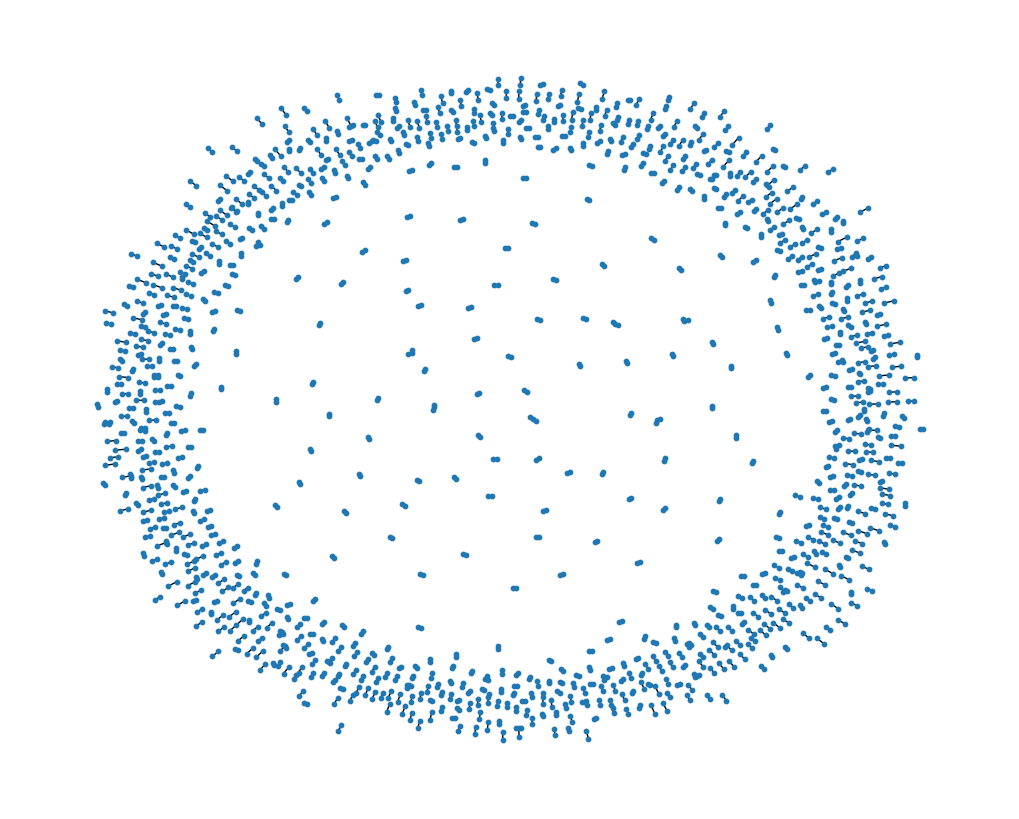

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add edges
sample_edges = edges.sample(1000)

for _, row in sample_edges.iterrows():
    G.add_edge(row["source"], row["target"])

# Draw graph
plt.figure(figsize=(10, 8))
nx.draw(G, node_size=10, with_labels=False)
plt.show()

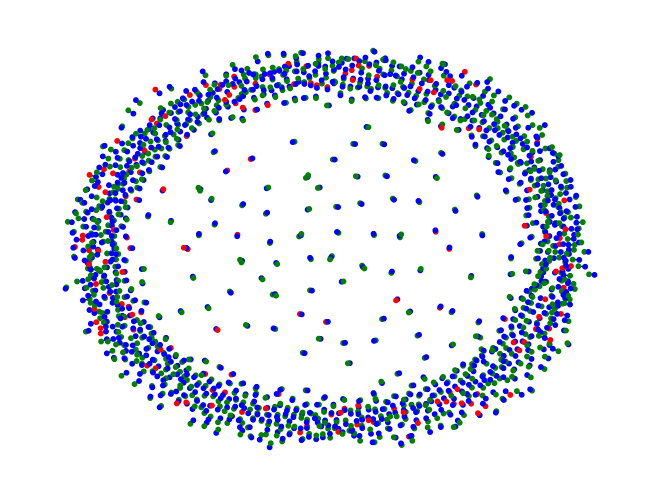

In [27]:
color_map = []

for node in G.nodes():
    if "txn" in node:
        txn_id = int(node.split("_")[1])
        fraud_val = data.loc[data["transaction_id"] == txn_id, "fraud"].values[0]
        color_map.append("red" if fraud_val == 1 else "green")
    else:
        color_map.append("blue")

nx.draw(G, node_color=color_map, node_size=10)
plt.show()

[[25673  7917]
 [  220  6190]]


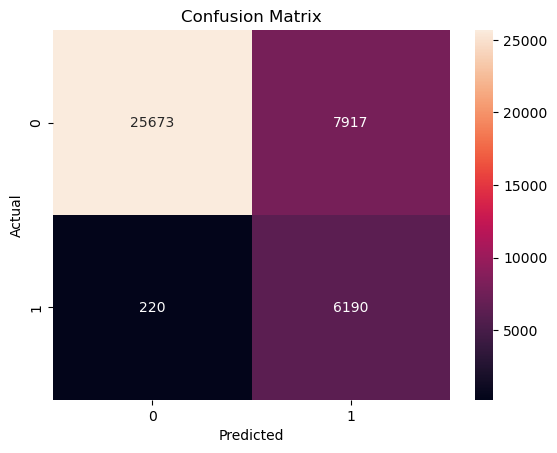

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Heatmap.png")
plt.show()

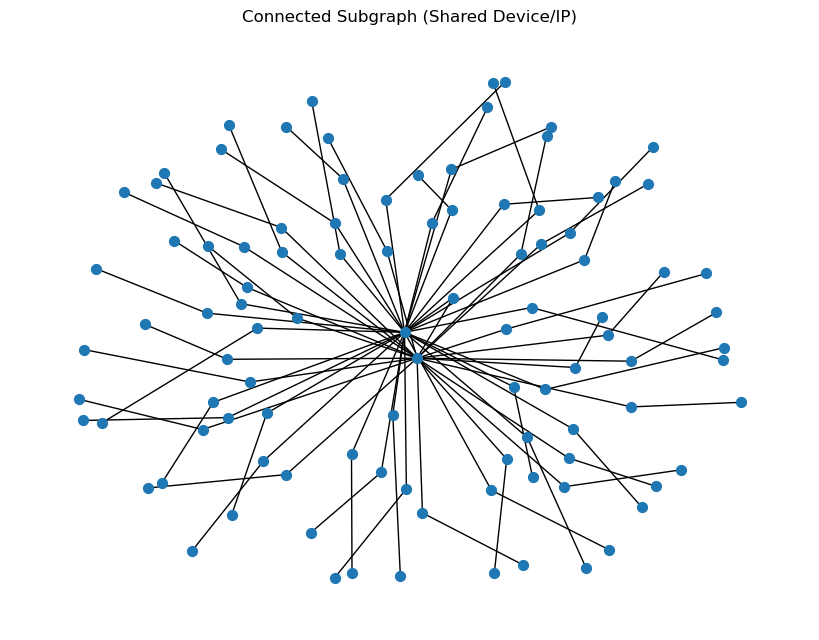

In [35]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()


txn_row = data.sample(1).iloc[0]

txn_node = f"txn_{txn_row['transaction_id']}"
device = txn_row["device_id"]
ip = txn_row["ip_id"]

# Add core edges
G.add_edge(txn_node, device)
G.add_edge(txn_node, ip)

# Add more transactions using same device/IP
related_txns = data[
    (data["device_id"] == device) | (data["ip_id"] == ip)
].head(50)

for _, row in related_txns.iterrows():
    t = f"txn_{row['transaction_id']}"
    G.add_edge(t, row["device_id"])
    G.add_edge(t, row["ip_id"])

# Layout
pos = nx.spring_layout(G, k=0.5)


plt.figure(figsize=(8, 6))
nx.draw(G, pos, node_size=50, with_labels=False)
plt.title("Connected Subgraph (Shared Device/IP)")
plt.savefig("graph1.png")
plt.show()


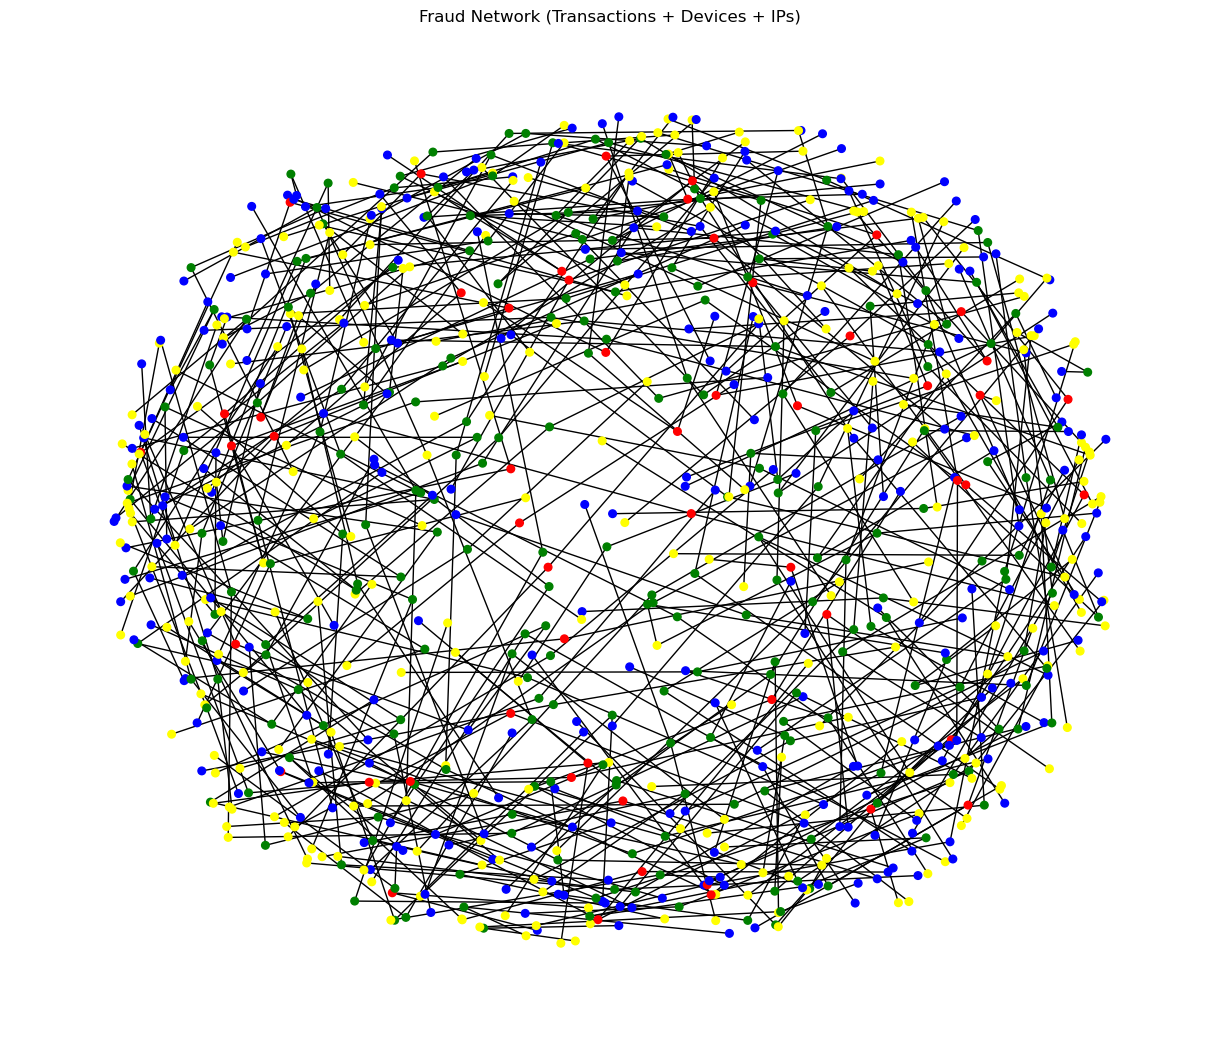

In [36]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()


txn_sample = data.sample(300, random_state=42)


for _, row in txn_sample.iterrows():
    txn_node = f"txn_{row['transaction_id']}"
    device = row["device_id"]
    ip = row["ip_id"]
    
    G.add_edge(txn_node, device)
    G.add_edge(txn_node, ip)


color_map = []

for node in G.nodes():
    if node.startswith("txn"):
        txn_id = int(node.split("_")[1])
        fraud_val = data.loc[data["transaction_id"] == txn_id, "fraud"].values[0]
        color_map.append("red" if fraud_val == 1 else "green")
    elif node.startswith("device"):
        color_map.append("blue")
    else:
        color_map.append("yellow") 


pos = nx.spring_layout(G, k=0.2, iterations=30)


plt.figure(figsize=(12, 10))
nx.draw(
    G,
    pos,
    node_color=color_map,
    node_size=30,
    with_labels=False
)

plt.title("Fraud Network (Transactions + Devices + IPs)")
plt.savefig("Fraud Network including Transactions, Devices and IPs.png")
plt.show()

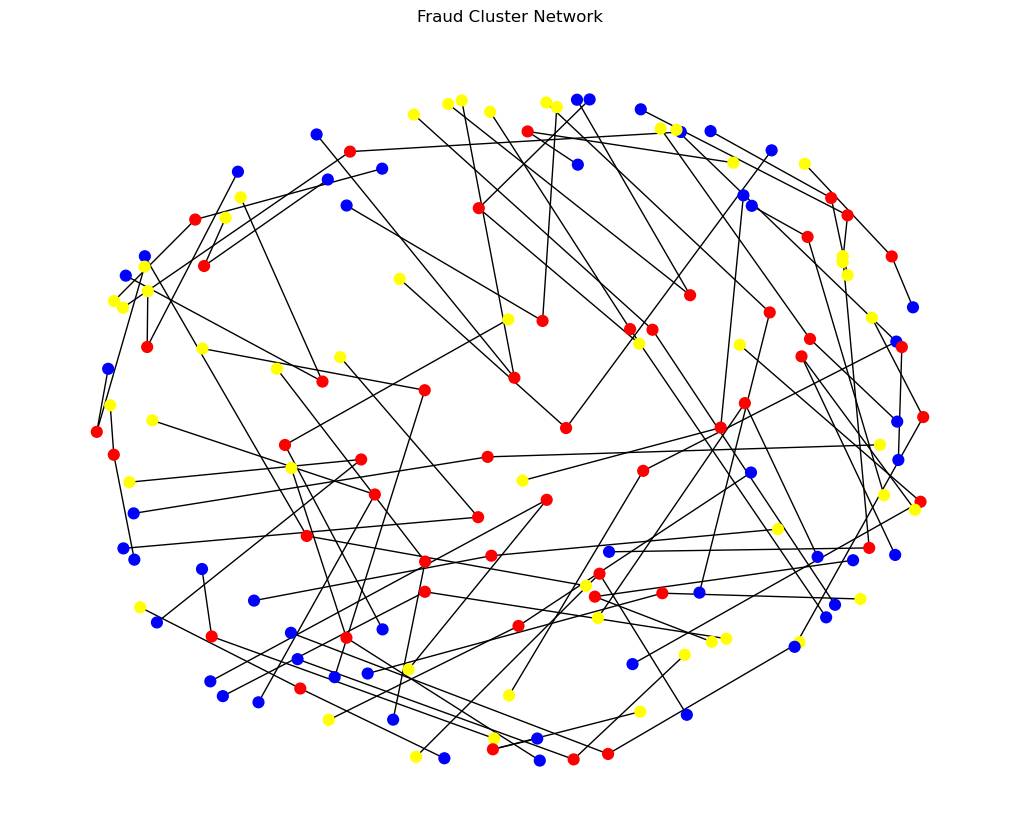

In [31]:
G = nx.Graph()

# Only fraud transactions
fraud_sample = data[data["fraud"] == 1].sample(50, random_state=42)

for _, row in fraud_sample.iterrows():
    txn = f"txn_{row['transaction_id']}"
    device = row["device_id"]
    ip = row["ip_id"]

    G.add_edge(txn, device)
    G.add_edge(txn, ip)


color_map = []

for node in G.nodes():
    if node.startswith("txn"):
        txn_id = int(node.split("_")[1])
        fraud_val = data.loc[data["transaction_id"] == txn_id, "fraud"].values[0]
        color_map.append("red" if fraud_val == 1 else "green")
    elif node.startswith("device"):
        color_map.append("blue")
    else:
        color_map.append("yellow")


pos = nx.spring_layout(G, k=0.6)


plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_color=color_map, node_size=60, with_labels=False)
plt.title("Fraud Cluster Network")
plt.show()

In [32]:
# For GenAI - New Notebook
torch.save({
    'graph_data': graph_data,
    'pred': pred,
    'probs': probs,
    'test_idx': test_idx
}, 'gnn_outputs.pt')

In [33]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

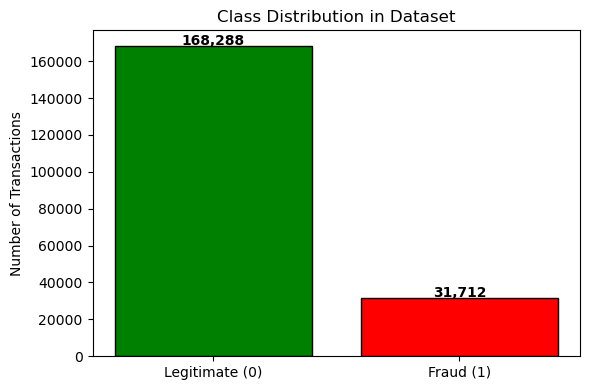

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("gnn_fraud_dataset.csv")

counts = data['fraud'].value_counts()
labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#2196F3', '#F44336']

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values, color=('green','red'), edgecolor='black', 
        width=0.8)
plt.ylabel('Number of Transactions')
plt.title('Class Distribution in Dataset')
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('Class_Distribution.png', dpi=150)
plt.show()

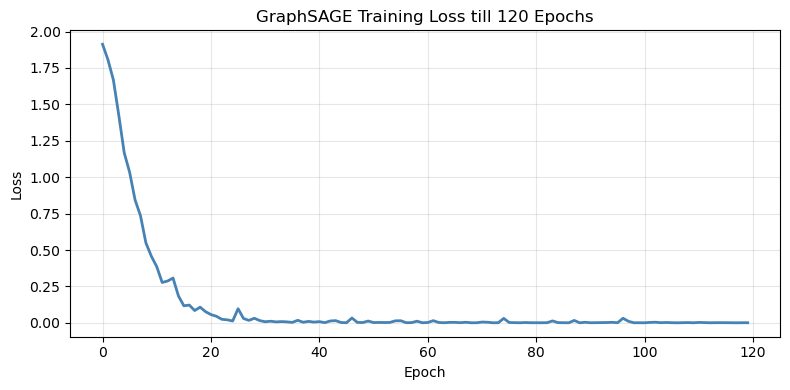

In [15]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import matplotlib.pyplot as plt

from torch_geometric.datasets import Planetoid  


dataset = Planetoid(root='/tmp/Cora', name='Cora')
graph_data = dataset[0]  
y = graph_data.y  


if not hasattr(graph_data, 'train_mask'):
    train_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
    train_mask[:int(0.8 * graph_data.num_nodes)] = True  
    graph_data.train_mask = train_mask
else:
    train_mask = graph_data.train_mask


num_classes = dataset.num_classes  

class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim=dataset.num_features):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, 32)
        self.conv2 = SAGEConv(32, 16)
        self.conv3 = SAGEConv(16, num_classes)  

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv3(x, edge_index)
        return x

losses = []
model = GraphSAGE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


class_weights = torch.ones(num_classes)  
class_weights[1] = 5.0  

for epoch in range(120):
    model.train()
    optimizer.zero_grad()
    out = model(graph_data)
    loss = F.cross_entropy(out[train_mask], y[train_mask],
                           weight=class_weights)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(range(120), losses, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GraphSAGE Training Loss till 120 Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Training_Loss_Curve.png', dpi=150)
plt.show()